<a href="https://colab.research.google.com/github/emanaak04-svg/sleep-apnea-detection/blob/main/amna/eeg_feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 01: Install Libraries and Mount Google Drive
We install required libraries and connect Google Drive
to access the saved EEG dataset.

In [2]:
!pip install wfdb -q

from google.colab import drive
drive.mount('/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported")

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
All libraries imported


## 02: Load the Saved EEG Dataset
We load the segmented EEG windows and labels that we saved
. Each row in X_eeg is one 30-second EEG window
with 7500 samples. y_labels contains 0 (normal) or 1 (apnea).

In [3]:
X_eeg = np.load("/drive/MyDrive/shhs-data/X_eeg.npy")
y = np.load("/drive/MyDrive/shhs-data/y_labels.npy")

print(f"Dataset loaded")
print(f"X_eeg shape : {X_eeg.shape}")
print(f"y shape     : {y.shape}")
print(f"Normal      : {np.sum(y==0)}")
print(f"Apnea       : {np.sum(y==1)}")

Dataset loaded
X_eeg shape : (2754, 7500)
y shape     : (2754,)
Normal      : 2389
Apnea       : 365


## 03: Extract EEG Band Power Features from One Window
EEG signals contain different frequency bands that reflect
different brain states during sleep:
- Delta (0.5-4 Hz): deep sleep waves
- Theta (4-8 Hz): light sleep waves  
- Alpha (8-13 Hz): relaxed wakefulness
- Beta (13-30 Hz): active thinking, arousal
During apnea the brain briefly wakes up which causes
changes in these frequency bands — especially delta and beta.
We also extract the ratio of delta to beta as a feature.

In [4]:
def extract_eeg_features(eeg_window, fs=250):
    # Use Welch method to estimate power spectral density
    freqs, psd = welch(eeg_window, fs=fs, nperseg=min(256, len(eeg_window)))

    # Extract band power for each frequency band
    def band_power(freqs, psd, low, high):
        idx = np.logical_and(freqs >= low, freqs < high)
        return np.trapz(psd[idx], freqs[idx])

    delta = band_power(freqs, psd, 0.5, 4)    # deep sleep
    theta = band_power(freqs, psd, 4, 8)       # light sleep
    alpha = band_power(freqs, psd, 8, 13)      # relaxed
    beta  = band_power(freqs, psd, 13, 30)     # arousal

    total = delta + theta + alpha + beta

    # Relative band powers (normalized)
    rel_delta = delta / total if total > 0 else 0
    rel_theta = theta / total if total > 0 else 0
    rel_alpha = alpha / total if total > 0 else 0
    rel_beta  = beta  / total if total > 0 else 0

    # Delta/Beta ratio — key feature for sleep apnea
    delta_beta_ratio = delta / beta if beta > 0 else 0

    return {
        'delta_power': delta,
        'theta_power': theta,
        'alpha_power': alpha,
        'beta_power': beta,
        'rel_delta': rel_delta,
        'rel_theta': rel_theta,
        'rel_alpha': rel_alpha,
        'rel_beta': rel_beta,
        'delta_beta_ratio': delta_beta_ratio
    }

# Test on first window
features = extract_eeg_features(X_eeg[0], fs=250)
print("EEG features extracted from first window")
print(f"\nSample features:")
for key, val in features.items():
    print(f"  {key:20s}: {val:.6f}")

EEG features extracted from first window

Sample features:
  delta_power         : 0.000638
  theta_power         : 0.000031
  alpha_power         : 0.000036
  beta_power          : 0.000013
  rel_delta           : 0.888355
  rel_theta           : 0.043225
  rel_alpha           : 0.050798
  rel_beta            : 0.017622
  delta_beta_ratio    : 50.412634


## 04: Extract EEG Features for All 2754 Windows
We apply the feature extraction function to every single
EEG window in our dataset. This converts raw brain wave
signals into a structured feature table with 9 features
per window ready for machine learning.

In [5]:
all_features = []
valid_labels = []
skipped = 0

for i in range(len(X_eeg)):
    features = extract_eeg_features(X_eeg[i], fs=250)
    if features is not None:
        all_features.append(features)
        valid_labels.append(y[i])
    else:
        skipped += 1

df_features = pd.DataFrame(all_features)
df_features['label'] = valid_labels

print(f"Feature extraction complete")
print(f"Total windows    : {len(X_eeg)}")
print(f"Valid windows    : {len(df_features)}")
print(f"Skipped windows  : {skipped}")
print(f"\nFeature table shape: {df_features.shape}")
print(f"\nFirst 5 rows:")
print(df_features.head())

Feature extraction complete
Total windows    : 2754
Valid windows    : 2754
Skipped windows  : 0

Feature table shape: (2754, 10)

First 5 rows:
   delta_power  theta_power  alpha_power  beta_power  rel_delta  rel_theta  \
0     0.000638     0.000031     0.000036    0.000013   0.888355   0.043225   
1     0.000646     0.000043     0.000050    0.000012   0.859899   0.056649   
2     0.000524     0.000039     0.000050    0.000012   0.838273   0.062108   
3     0.000803     0.000043     0.000037    0.000012   0.897794   0.048063   
4     0.000523     0.000032     0.000036    0.000012   0.866945   0.053552   

   rel_alpha  rel_beta  delta_beta_ratio  label  
0   0.050798  0.017622         50.412634      1  
1   0.067037  0.016415         52.384356      1  
2   0.080058  0.019561         42.855374      1  
3   0.040840  0.013302         67.491711      0  
4   0.058904  0.020599         42.087581      0  


## 05: Visualize EEG Features — Apnea vs Normal
We plot the distribution of each EEG band power feature
comparing apnea windows vs normal windows.
If the distributions look different the feature is useful
for detecting apnea.

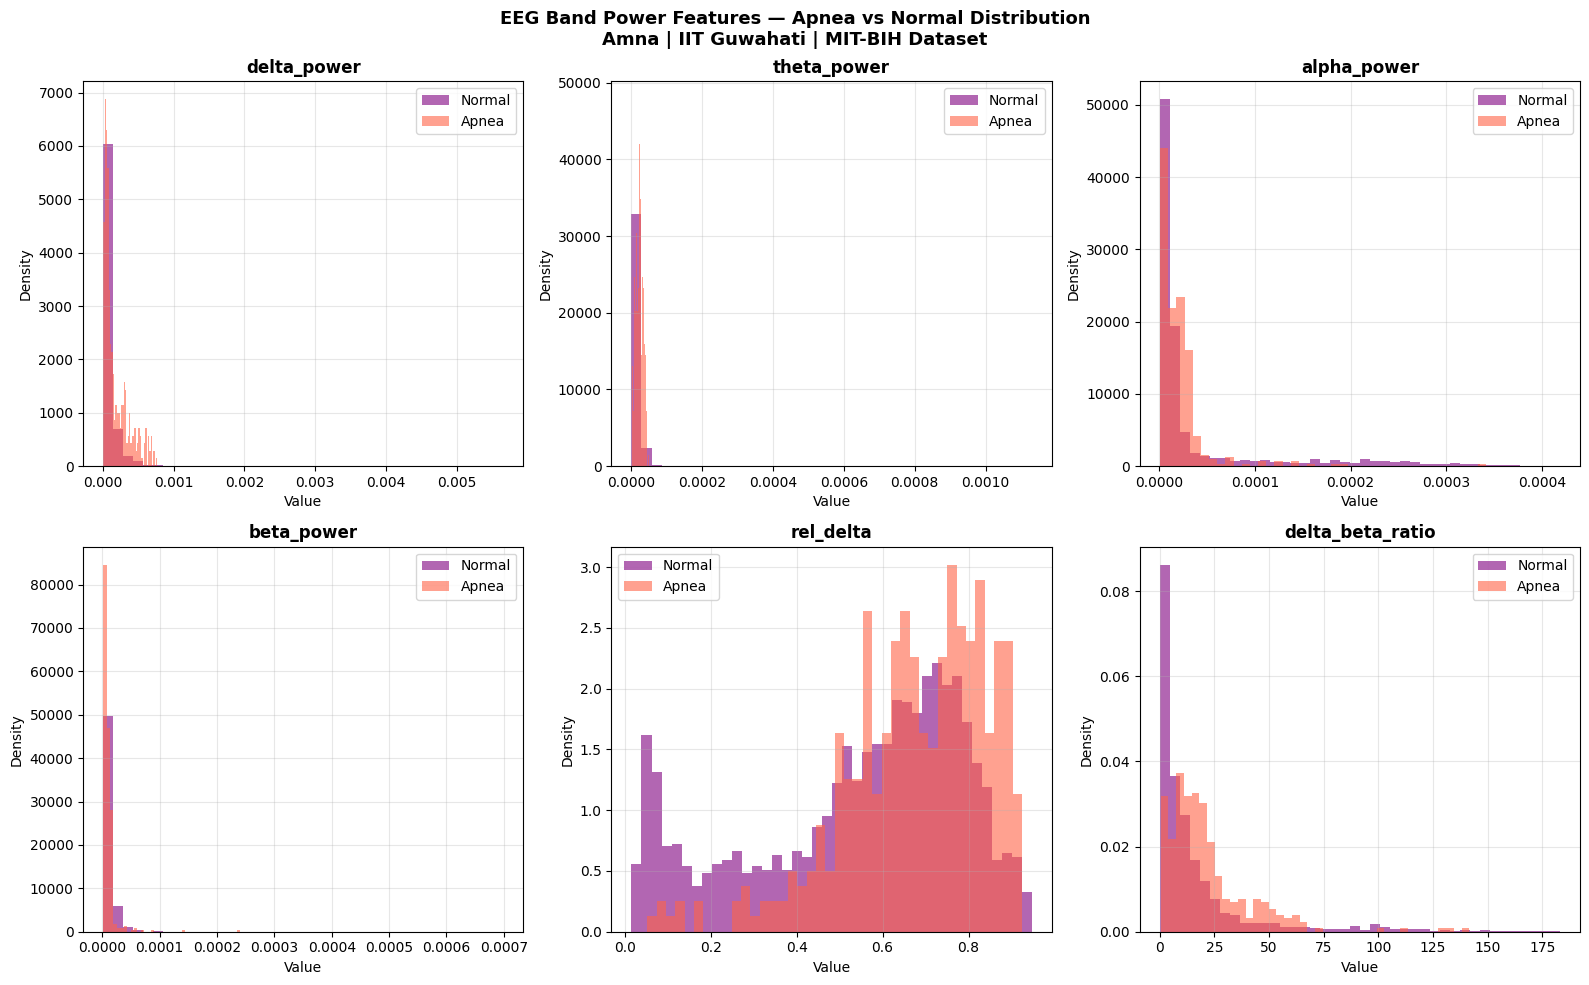

Plot saved


In [6]:
features_to_plot = ['delta_power', 'theta_power', 'alpha_power', 'beta_power',
                    'rel_delta', 'delta_beta_ratio']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("EEG Band Power Features — Apnea vs Normal Distribution\nAmna | IIT Guwahati | MIT-BIH Dataset",
             fontsize=13, fontweight='bold')

normal_df = df_features[df_features['label'] == 0]
apnea_df  = df_features[df_features['label'] == 1]

for idx, feat in enumerate(features_to_plot):
    ax = axes[idx // 3][idx % 3]
    ax.hist(normal_df[feat], bins=40, alpha=0.6, color='purple', label='Normal', density=True)
    ax.hist(apnea_df[feat],  bins=40, alpha=0.6, color='tomato', label='Apnea',  density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/drive/MyDrive/shhs-data/eeg_features_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

## 06: Save the EEG Feature Table
We save the complete EEG feature table as a CSV file.
This file will be used when we merge ECG, EEG,
and respiratory features into one final table for training.

In [7]:
df_features.to_csv("/drive/MyDrive/shhs-data/eeg_band_features.csv", index=False)

print(f"Features saved")
print(f"File: eeg_band_features.csv")
print(f"Shape: {df_features.shape}")
print(f"\nColumns: {list(df_features.columns)}")

Features saved
File: eeg_band_features.csv
Shape: (2754, 10)

Columns: ['delta_power', 'theta_power', 'alpha_power', 'beta_power', 'rel_delta', 'rel_theta', 'rel_alpha', 'rel_beta', 'delta_beta_ratio', 'label']
